# Notebook 6 — Exploratory Data Analysis

## Block 0 — Load pipeline outputs and build the person-level analytical table

The two ML deliverables (binary departure prediction, trajectory clustering) operate at the
**person level**, so the EDA starts at that granularity. We load the outputs of Notebook 5
(`episodes.parquet`, `absences.parquet`) and the Notebook 3 target (`person_target`), then
build one analytical table with **one row per `id_projet`**.

Two populations are combined:
1. **Event generators** (individuals present in `person_target`), carrying the
   NB3 departure target.
2. **Sedentary residents** (single censored episode 0, absent from
   `person_target`): they never generated a chainable mutation event and are
   reintegrated here as *certain non-departures* (`target_depart = 0`,
   `is_sedentaire = 1`). The NB5 seed-only count is an upper bound of this
   population (it also contains individuals whose events were all consolidated
   away before chaining); the exact figure and the reconciliation are
   established in Block 0bis.

First trajectory features derived from the episode table:
- `n_episodes`: number of residential episodes (1–19)
- `duree_totale_j` / `duree_median_ep_j`: total and median observed episode duration
- `censure`: whether the last episode is right-censored (individual still resident)
- `n_absences`: number of temporary absences (from `absences.parquet`)
- `debut_type_premier`: how the trajectory starts (snapshot bootstrap, birth, arrival, ...)

Sanity checks at the end: row count = event generators + sedentary, no duplicated
`id_projet`, target distribution reconciled against the NB3 rate (the gap is explained by
the target-only exclusions of Block 0bis).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# --- Paths (project conventions) ---
DATA_DIR = Path("/mnt/o/09_STATISTIQUES/09_04_Explorations/MR/CAS ADS/Final project/data")

def load_table(stem: str) -> pd.DataFrame:
    """Load a pipeline output, parquet first, csv.gz fallback."""
    pq, csv = DATA_DIR / f"{stem}.parquet", DATA_DIR / f"{stem}.csv.gz"
    if pq.exists():
        df = pd.read_parquet(pq)
    elif csv.exists():
        df = pd.read_csv(csv, compression="gzip")
    else:
        raise FileNotFoundError(f"Neither {pq.name} nor {csv.name} found in {DATA_DIR}")
    print(f"{stem:<20} {df.shape[0]:>9,} rows  x {df.shape[1]:>3} cols")
    return df

episodes      = load_table("episodes")
absences      = load_table("absences")
person_target = load_table("person_target")

# --- Person-level aggregation from the episode table ---
ep = episodes.sort_values(["id_projet", "ep_num"])

agg = (
    ep.groupby("id_projet")
      .agg(
          n_episodes        = ("ep_num", "size"),
          duree_totale_j    = ("duree_j", "sum"),
          duree_median_ep_j = ("duree_j", "median"),
          debut_type_premier= ("debut_type", "first"),
          fin_type_dernier  = ("fin_type", "last"),
          date_debut_premier= ("date_debut", "first"),
          date_fin_derniere = ("date_fin", "last"),
      )
      .reset_index()
)

# Right-censoring flag: last episode has no closing date
last_ep = ep.groupby("id_projet").tail(1)
agg["censure"] = agg["id_projet"].map(
    last_ep.set_index("id_projet")["date_fin"].isna()
).astype(int)

# Absences count (temporary absences, annex table)
n_abs = absences.groupby("id_projet").size().rename("n_absences")
agg = agg.merge(n_abs, on="id_projet", how="left")
agg["n_absences"] = agg["n_absences"].fillna(0).astype(int)

# --- Attach the departure target (validated in Notebook 3) ---
# 'departed' is the binary target: 1 = departure (confirmed / non-confirmed /
# anticipated with elapsed DATDEP), 0 = still present, death, or deleted record.
# 'depart_status' is kept to allow later scoping decisions (deaths, deleted records).
persons = agg.merge(
    person_target[["id_projet", "departed", "depart_status",
                   "ne_et_reside_depuis_naissance"]],
    on="id_projet", how="left",
)
persons = persons.rename(columns={"departed": "target_depart"})

# Sedentary residents: not in person_target -> certain non-departure
persons["is_sedentaire"] = persons["target_depart"].isna().astype(int)
persons["target_depart"] = persons["target_depart"].fillna(0).astype(int)
persons["depart_status"] = persons["depart_status"].fillna("sedentaire_present")
persons["ne_et_reside_depuis_naissance"] = (
    persons["ne_et_reside_depuis_naissance"].astype("boolean").fillna(False).astype(bool)
)

# --- Perimeter diagnostic: episodes vs person_target ---
ids_ep  = set(episodes["id_projet"].unique())
ids_tgt = set(person_target["id_projet"])
print("--- Perimeter diagnostic ---")
print(f"Individuals in episodes:              {len(ids_ep):,}")
print(f"Individuals in person_target:         {len(ids_tgt):,}")
print(f"In episodes, not in target (sedentary): {len(ids_ep - ids_tgt):,}")
print(f"In target, NOT in episodes:           {len(ids_tgt - ids_ep):,}")

# Who are the target-only individuals? (no residential episode built in NB5)
only_tgt = person_target[person_target["id_projet"].isin(ids_tgt - ids_ep)]
if len(only_tgt):
    print("\ndepart_status of target-only individuals:")
    print(only_tgt["depart_status"].value_counts())

# --- Sanity checks ---
print("\n--- Sanity checks ---")
print(f"Persons total (episode-based):  {len(persons):,}")
assert persons["id_projet"].is_unique, "Duplicate id_projet in person table!"

n_sed = persons["is_sedentaire"].sum()
print(f"Sedentary (NB5 seed-only count is an upper bound): {n_sed:,}")

gen = persons[persons["is_sedentaire"] == 0]
nb3_rate = person_target["departed"].mean()
print(f"Event generators with episodes: {len(gen):,}")
print(f"Departure rate (generators): {gen['target_depart'].mean():.1%}  "
      f"| NB3 rate on all target individuals: {nb3_rate:.1%}")
print("  (the gap reflects the target-only individuals excluded -- see Block 0bis)")
print(f"Departure rate (full table, incl. sedentary): {persons['target_depart'].mean():.1%}")

print(f"\ndepart_status distribution:")
print(persons["depart_status"].value_counts())

persons.head()

episodes               493,912 rows  x  15 cols
absences                 4,496 rows  x   4 cols
person_target          291,763 rows  x  10 cols
--- Perimeter diagnostic ---
Individuals in episodes:              310,746
Individuals in person_target:         291,763
In episodes, not in target (sedentary): 39,853
In target, NOT in episodes:           20,870

depart_status of target-only individuals:
depart_status
departed_confirmed           15736
present                       3532
dossier_supprime              1407
death                          174
pending_anticipated             10
departed_nonconfirmed            8
departed_anticipated_past        3
Name: count, dtype: int64

--- Sanity checks ---
Persons total (episode-based):  310,746
Sedentary (NB5 seed-only count is an upper bound): 39,853
Event generators with episodes: 270,893
Departure rate (generators): 55.6%  | NB3 rate on all target individuals: 57.1%
  (the gap reflects the target-only individuals excluded -- see Block 0bis

,id_projet,n_episodes,duree_totale_j,duree_median_ep_j,debut_type_premier,fin_type_dernier,date_debut_premier,date_fin_derniere,censure,n_absences,target_depart,depart_status,ne_et_reside_depuis_naissance,is_sedentaire
0,1000039,1,1244,1244.0,arrivee,depart,2020-04-01,2023-08-28,0,0,1,departed_confirmed,False,0
1,1000077,1,26083,26083.0,snapshot,censure,1955-01-01,NaT,1,0,0,sedentaire_present,False,1
2,1000112,1,14784,14784.0,snapshot,censure,1985-12-08,NaT,1,0,0,sedentaire_present,False,1
3,1000124,1,11884,11884.0,snapshot,depart_anticipe,1985-11-01,2018-05-16,0,0,1,departed_confirmed,False,0
4,1000186,1,24012,24012.0,snapshot,deces,1949-08-02,2015-04-30,0,0,0,death,False,0


## Block 0bis — Perimeter diagnostic: individuals with a target but no episode

Some individuals from `person_target` have no episode in `episodes.parquet`,
and the sedentary count differs from the NB5 seed-only figure. Most of the gap
is **by construction**: NB5 excluded (a) individuals whose entire history is in
secondary residence and (b) administratively wiped files (`dossier_supprime`) —
both leave `person_target` rows with no episode. The NB5 seed-only count, on
the other side, includes individuals who *do* have events (hence a
`person_target` row) but whose events were all consolidated away before
chaining. The classification below therefore reconciles the target-only
population against the known NB5 exclusions first, then profiles the residual
(annulation-dominated histories, single migratory events that cannot form an
interval). The outcome is a documented scoping decision for the Data section
of the report.

In [2]:
# Load the event table (NB3 output) to inspect target-only individuals
events = load_table("masterfile_events")

ids_only_tgt = ids_tgt - ids_ep
ev_only = events[events["id_projet"].isin(ids_only_tgt)]
print(f"Events belonging to target-only individuals: {len(ev_only):,} "
      f"({ev_only['id_projet'].nunique():,} individuals)")

# 1) What kind of events do they generate?
print("\n--- nature_evenement of their events ---")
print(ev_only["nature_evenement"].value_counts().head(12))

# 2) Do they have a usable dwelling identifier? (adapt column names if needed)
loc_cols = [c for c in ["EGID", "EWID", "loc"] if c in ev_only.columns]
print(f"\n--- Dwelling identifier completeness ({loc_cols}) ---")
for c in loc_cols:
    print(f"{c}: {ev_only[c].isna().mean():.1%} missing "
          f"(vs {events[c].isna().mean():.1%} in full event table)")

# 3) How many events per individual? (single-event people can't form a stay interval)
n_ev = ev_only.groupby("id_projet").size()
print(f"\nEvents per target-only individual: "
      f"median={n_ev.median():.0f}, share with 1 event={(n_ev == 1).mean():.1%}")

# 4) Cross-check the sedentary discrepancy: 43,607 vs 40,545
#    -> are there single-censored-episode-0 individuals who DO appear in person_target?
first_ep = episodes.sort_values(["id_projet", "ep_num"]).groupby("id_projet").first()
solo_censored_snap = first_ep[
    (first_ep.index.isin(  # exactly one episode
        episodes["id_projet"].value_counts()[lambda s: s == 1].index))
    & (first_ep["debut_type"] == "snapshot")
    & (first_ep["date_fin"].isna())
]
in_tgt = solo_censored_snap.index.isin(ids_tgt)
print(f"\nSingle censored snapshot-episode individuals: {len(solo_censored_snap):,}")
print(f"  of which IN person_target:     {in_tgt.sum():,}")
print(f"  of which NOT in person_target: {(~in_tgt).sum():,}  (= current sedentary def)")

masterfile_events      863,577 rows  x  71 cols
Events belonging to target-only individuals: 53,255 (20,870 individuals)

--- nature_evenement of their events ---
nature_evenement
migratoire       33770
annulation        9735
administratif     4672
menage            3284
residentiel       1581
demographique      187
absence             26
Name: count, dtype: int64

--- Dwelling identifier completeness (['EGID']) ---
EGID: 0.2% missing (vs 0.3% in full event table)

Events per target-only individual: median=2, share with 1 event=33.0%

Single censored snapshot-episode individuals: 45,597
  of which IN person_target:     5,744
  of which NOT in person_target: 39,853  (= current sedentary def)


In [3]:
# Classify target-only individuals by KNOWN cause, in priority order
tgt_only = person_target[person_target["id_projet"].isin(ids_only_tgt)] \
               .set_index("id_projet")

# (1) administratively wiped files -- excluded from NB5 by design
is_wiped = tgt_only["depart_status"].eq("dossier_supprime")

# (2) entire history in secondary residence -- excluded from NB5 by design
all_sec = (ev_only.groupby("id_projet")["TYPAD_C"]
                  .agg(lambda s: s.eq("Secondaire").all())
                  .reindex(tgt_only.index, fill_value=False))

# (3) residual: event patterns that cannot form a stay
pat = ev_only.groupby("id_projet")["nature_evenement"].agg(
    n_events="size",
    has_annulation=lambda s: (s == "annulation").any(),
    n_migratoire=lambda s: (s == "migratoire").sum(),
).reindex(tgt_only.index)

cause = pd.Series("autre (a inspecter)", index=tgt_only.index)
cause[(pat["n_events"] == 1) & (pat["n_migratoire"] == 1)] = \
    "single migratory event (no interval possible)"
cause[pat["has_annulation"].fillna(False).astype(bool)] = \
    "history dominated by annulations"
cause[all_sec.astype(bool)] = "entirely secondary residence (NB5 scope)"
cause[is_wiped] = "dossier_supprime (NB5 scope)"

print(f"Target-only individuals: {len(tgt_only):,}")
print(cause.value_counts().to_string())
print(f"\nResidual to inspect: {(cause == 'autre (a inspecter)').sum():,}")

Target-only individuals: 20,870
entirely secondary residence (NB5 scope)         13690
history dominated by annulations                  4732
dossier_supprime (NB5 scope)                      1407
autre (a inspecter)                                956
single migratory event (no interval possible)       85

Residual to inspect: 956


## Block 1 — Person-level descriptive statistics

Modelling population: the individuals with at least one reconstructed episode.
Scoping decisions documented above: target-only individuals excluded — mostly
by construction (entirely-secondary histories and wiped files are outside the
NB5 perimeter), the residual having no reconstructible stay; sedentary =
single censored episode 0 absent from `person_target`, reintegrated as certain
non-departures.

This block produces the descriptive table for the EDA section (counts, departure rates,
episode counts, durations, absences — overall and by key subgroups) and persists the
analytical table for the next blocks and the ML notebooks.

In [4]:
# --- Persist the analytical table ---
out_path = DATA_DIR / "persons_analytical.parquet"
persons.to_parquet(out_path, index=False)
print(f"Saved {len(persons):,} rows -> {out_path.name}\n")

# --- Global descriptives ---
print("=== Modelling population ===")
print(f"Individuals:        {len(persons):,}")
print(f"Departure rate:     {persons['target_depart'].mean():.1%}")
print(f"Right-censored:     {persons['censure'].mean():.1%}")
print(f"Born & resident since birth: {persons['ne_et_reside_depuis_naissance'].mean():.1%}")

print("\n=== Episodes per person ===")
print(persons["n_episodes"].describe().round(2))
print(f"Share with 1 episode: {(persons['n_episodes']==1).mean():.1%}")
print(f"Share with 3+:        {(persons['n_episodes']>=3).mean():.1%}")

print("\n=== Total observed duration (days) ===")
print(persons["duree_totale_j"].describe().round(0))

print("\n=== Departure rate by number of episodes ===")
tab_ep = (persons.groupby(persons["n_episodes"].clip(upper=5))["target_depart"]
          .agg(n="size", taux_depart="mean").round(3))
tab_ep.index = [str(int(i)) if i < 5 else "5+" for i in tab_ep.index]  # matches Figure 3
print(tab_ep)

print("\n=== Departure rate by trajectory start type ===")
print(persons.groupby("debut_type_premier")["target_depart"]
      .agg(n="size", taux_depart="mean").round(3))

print("\n=== Absences ===")
print(f"Persons with >=1 absence: {(persons['n_absences']>0).sum():,} "
      f"({(persons['n_absences']>0).mean():.2%})")

Saved 310,746 rows -> persons_analytical.parquet

=== Modelling population ===
Individuals:        310,746
Departure rate:     48.5%
Right-censored:     51.1%
Born & resident since birth: 10.6%

=== Episodes per person ===
count    310746.00
mean          1.59
std           0.93
min           1.00
25%           1.00
50%           1.00
75%           2.00
max          17.00
Name: n_episodes, dtype: float64
Share with 1 episode: 61.2%
Share with 3+:        13.1%

=== Total observed duration (days) ===
count    310746.0
mean       4622.0
std        5805.0
min           0.0
25%         642.0
50%        2227.0
75%        6390.0
max       39035.0
Name: duree_totale_j, dtype: float64

=== Departure rate by number of episodes ===
         n  taux_depart
1   190041        0.533
2    80115        0.432
3    26562        0.383
4     9124        0.351
5+    4904        0.308

=== Departure rate by trajectory start type ===
                         n  taux_depart
debut_type_premier                  

## Block 1bis — Demographic and household entry attributes (enriched analytical table)

Entry attributes are extracted from two sources, following the entry-point rule:
individuals whose trajectory starts with the 2014 snapshot take their attributes
from `population_2014` (their state when observation begins); all others take
them from their earliest event (sorted by `MUTATION_DATE`). Time-invariant
fields (birth date, sex) are coalesced from both sources. This rule avoids a
temporal leak: for a 2014-stock individual, the first *event* may occur years
into the observed trajectory and would describe a mid-trajectory state, not the
state at entry.

Derived features (all known at entry, leakage-free):

- `age_entree`: age when observation starts (`AgeCivil` for the 2014 stock,
  age at first episode start otherwise);
- `sexe`: M / F (a residual 'I' = unknown, ~20 individuals);
- `nat_groupe`: CH / UE_AELE / tiers. The register stores country *names*
  (not OFS codes): 'Suisse' identifies Swiss nationals; EU/EFTA membership is
  identified by the country-name list of the CeAele permit regime, backed by
  the legal regime field `TYPERM_C` on the event side;
- `permis_groupe`: CH (no permit) / C / B / L / P (pending application, the
  typical status of a freshly registered arrival) / asile (F, N, S) / autre;
- `prov_groupe`: etranger / vaud / autre_canton / inconnue, from the
  provenance country (names or codes handled) and the OFS commune range
  5401-5999 for Vaud (validated on top communes: Lausanne, Renens, Prilly,
  Pully);
- `menage_taille`: `PERSMEN` at first event; for the 2014 stock, computed by
  counting snapshot members per household identifier;
- `menage_type`: Prive / Collectif / Administratif / HorsCommune;
- `pieces`, `surface`: dwelling at entry (RCB source), ~7% missing.

Religion is available in both sources but excluded on relevance and
sensitivity grounds. Destination fields (`COMDEST`, `PAYSDEST`, `DATDEP`) are
excluded as direct outcome proxies. The enriched table is saved as
`persons_analytical_enriched.parquet` and is the input of the modelling
notebook (NB7).

In [5]:
# ============ Block 1bis: entry attributes from events + snapshot ============
# EU/EFTA country names, from the CeAele regime list in the BDCH permit
# catalogue; Croatia added (EU member since 2013, list predates accession).
UE_AELE_NOMS = {
    "Allemagne", "Autriche", "Belgique", "Bulgarie", "Chypre", "Croatie",
    "Danemark", "Espagne", "Estonie", "Finlande", "France", "Grèce",
    "Hongrie", "Irlande", "Islande", "Italie", "Lettonie", "Lituanie",
    "Liechtenstein", "Luxembourg", "Malte", "Norvège", "Pays-Bas",
    "Pologne", "Portugal", "République slovaque", "République tchèque",
    "Roumanie", "Slovénie", "Suède",
}

DEMO_COLS = ["DATNAIS", "CODE_SEXE", "NATION", "TYPERM_C", "PERMIS_C",
             "ETAT_CIVIL", "PAYSPROVN", "COMPROV",
             "PERSMEN", "TYPE_MENAGE", "NOMBRE_PIECE", "SURFACE"]

# --- Source 1: earliest event per individual (cached) ---
p_cache = DATA_DIR / "entry_attributes_events.parquet"
if p_cache.exists():
    first_ev = pd.read_parquet(p_cache)
else:
    ev = load_table("masterfile_events")
    first_ev = (
        ev.sort_values(["id_projet", "MUTATION_DATE", "DATE_EFFECTIVE"])
          .groupby("id_projet", as_index=False)
          .first()[["id_projet"] + DEMO_COLS]
    )
    first_ev.to_parquet(p_cache, index=False)
print(f"First-event attributes: {len(first_ev):,} individuals")

# --- Source 2: 2014 snapshot ---
snap = pd.read_parquet(DATA_DIR / "population_2014.parquet")
snap["menage_taille_snap"] = snap.groupby("NUMERO_MENAGE")["id_projet"].transform("size")
ch_share = (snap["Nation (CH/Etr)"].astype(str).str.upper()
            .str.startswith(("CH", "SUISSE"))).mean()
print(f"Snapshot: {len(snap):,} rows, CH share {ch_share:.1%}")

snap_attr = snap[["id_projet", "DATNAIS", "CODE_SEXE", "AgeCivil", "NationCa",
                  "Nation (CH/Etr)", "Permis", "ETAT_CIVIL", "PAYSPROVN",
                  "COMPROV", "menage_taille_snap", "TYPE_MENAGE",
                  "NOMBRE_PIECE", "SURFACE"]].copy()

# --- Merge onto the analytical table, entry-point rule ---
pers = persons.copy()  # built in Block 1 above
pers = pers.merge(first_ev.add_suffix("_ev").rename(columns={"id_projet_ev": "id_projet"}),
                  on="id_projet", how="left")
pers = pers.merge(snap_attr.add_suffix("_sn").rename(columns={"id_projet_sn": "id_projet"}),
                  on="id_projet", how="left")

is_snap = pers["debut_type_premier"].eq("snapshot") | pers["is_sedentaire"].eq(1)
print(f"Entry source: snapshot for {is_snap.sum():,}, first event for {(~is_snap).sum():,}")

def pick(col_sn, col_ev):
    """Snapshot value for the 2014 stock, first-event value otherwise."""
    return pers[col_sn].where(is_snap, pers[col_ev])

# --- Invariants: coalesce, with explicit parsing and guards (date-bug lesson) ---
dn_ev = pd.to_datetime(pers["DATNAIS_ev"], errors="coerce")
dn_sn = pd.to_datetime(pers["DATNAIS_sn"], errors="coerce")
pers["datnais"] = dn_ev.fillna(dn_sn)
assert pers["datnais"].isna().mean() < 0.001, "Unexpected missing birth dates"
pers["sexe"] = (pers["CODE_SEXE_ev"].fillna(pers["CODE_SEXE_sn"])
                .astype(str).str[0].str.upper())

# --- Age at entry into observation (AgeCivil stored as string -> numeric) ---
age_ev = (pers["date_debut_premier"] - pers["datnais"]).dt.days / 365.25
age_sn = pd.to_numeric(pers["AgeCivil_sn"], errors="coerce")
pers["age_entree"] = np.where(is_snap, age_sn, age_ev).astype(float)

# (1) Birth entries are age 0 by construction (fixes DATNAIS/episode-date
#     inconsistencies observed on 9 records).
pers.loc[pers["debut_type_premier"] == "naissance", "age_entree"] = 0.0

# (2) Residual negatives: offsets under 1 year are administrative -> clip to 0;
#     larger discrepancies are register errors -> NaN, documented.
neg = pers["age_entree"] < 0
n_clip = (neg & (pers["age_entree"] > -1)).sum()
n_nan  = (neg & (pers["age_entree"] <= -1)).sum()
print(f"Negative ages after birth rule: {n_clip} clipped to 0, {n_nan} set to NaN")
pers.loc[neg & (pers["age_entree"] > -1), "age_entree"] = 0.0
pers.loc[neg & (pers["age_entree"] <= -1), "age_entree"] = np.nan
assert (pers["age_entree"].dropna() >= 0).all()

# (3) Implausibly high ages (> 110): register errors -> NaN, documented
n_high = (pers["age_entree"] > 110).sum()
print(f"Ages above 110 set to NaN: {n_high}")
pers.loc[pers["age_entree"] > 110, "age_entree"] = np.nan

# Validation: plausible distribution overall and by entry type
print("\nage_entree:", pers["age_entree"].describe().round(1).to_dict())
print(pers.groupby("debut_type_premier")["age_entree"]
      .agg(["median", "count"]).round(1).to_string())

# --- Nationality group (NATION holds country NAMES, not OFS codes) ---
nat_ev = np.select(
    [pers["NATION_ev"] == "Suisse",
     pers["NATION_ev"].isin(UE_AELE_NOMS) | (pers["TYPERM_C_ev"] == "CeAele")],
    ["CH", "UE_AELE"], default="tiers")
ch_sn = (pers["Nation (CH/Etr)_sn"].astype(str).str.upper()
         .str.startswith(("CH", "SUISSE")))
nat_sn = np.select(
    [ch_sn, pers["NationCa_sn"].isin(UE_AELE_NOMS)],
    ["CH", "UE_AELE"], default="tiers")
pers["nat_groupe"] = np.where(is_snap, nat_sn, nat_ev)

# --- Permit group, with P (pending application) as its own category ---
def permit_group(s, is_ch):
    s = s.astype(str).str.strip().str.upper()
    return np.select(
        [is_ch, s == "C", s == "B", s == "L", s == "P", s.isin(["F", "N", "S"])],
        ["CH", "C", "B", "L", "P", "asile"], default="autre")

pers["permis_groupe"] = np.where(
    is_snap,
    permit_group(pers["Permis_sn"],   nat_sn == "CH"),
    permit_group(pers["PERMIS_C_ev"], nat_ev == "CH"),
)

# --- Provenance group (robust to names or codes; Vaud = OFS 5401-5999) ---
def prov_is_ch(s):
    s2 = s.astype(str).str.strip()
    return s2.eq("Suisse") | s2.eq("8100") | s2.eq("8100.0")

paysprov = pick("PAYSPROVN_sn", "PAYSPROVN_ev")
comprov  = pd.to_numeric(pick("COMPROV_sn", "COMPROV_ev"), errors="coerce")
pers["prov_groupe"] = np.select(
    [paysprov.notna() & ~prov_is_ch(paysprov),
     comprov.between(5401, 5999),
     comprov.notna()],
    ["etranger", "vaud", "autre_canton"], default="inconnue")

# --- Household and dwelling at entry ---
pers["menage_taille"] = pd.to_numeric(pick("menage_taille_snap_sn", "PERSMEN_ev"),
                                      errors="coerce")
pers["menage_type"] = pick("TYPE_MENAGE_sn", "TYPE_MENAGE_ev").fillna("inconnu")
pers["pieces"]  = pd.to_numeric(pick("NOMBRE_PIECE_sn", "NOMBRE_PIECE_ev"), errors="coerce")
pers["surface"] = pd.to_numeric(pick("SURFACE_sn", "SURFACE_ev"), errors="coerce")

# --- Diagnostics ---
NEW_FEATS = ["age_entree", "sexe", "nat_groupe", "permis_groupe",
             "prov_groupe", "menage_taille", "menage_type", "pieces", "surface"]
print("\n=== New entry features: missingness ===")
print(pers[NEW_FEATS].isna().mean().round(3).to_string())
print("\n=== age_entree ===")
print(pers["age_entree"].describe().round(1).to_string())
print("\nnat_groupe:   ", pers["nat_groupe"].value_counts().to_dict())
print("permis_groupe:", pers["permis_groupe"].value_counts().to_dict())
print("prov_groupe:  ", pers["prov_groupe"].value_counts().to_dict())
print("menage_type:  ", pers["menage_type"].value_counts().to_dict())
print("sexe:         ", pers["sexe"].value_counts(dropna=False).to_dict())
print("\n=== Departure rate by new categorical features ===")
for c in ["nat_groupe", "permis_groupe", "prov_groupe", "menage_type", "sexe"]:
    print(f"\n{c}:")
    print(pers.groupby(c)["target_depart"].agg(n="size", taux="mean").round(3).to_string())

# --- Save enriched table (drop auxiliary source columns) ---
drop_aux = [c for c in pers.columns if c.endswith(("_ev", "_sn"))]
out = pers.drop(columns=drop_aux)
out.to_parquet(DATA_DIR / "persons_analytical_enriched.parquet", index=False)
print(f"\nSaved persons_analytical_enriched.parquet "
      f"({len(out):,} rows x {out.shape[1]} cols)")


First-event attributes: 291,763 individuals
Snapshot: 140,228 rows, CH share 57.7%
Entry source: snapshot for 140,000, first event for 170,746
Negative ages after birth rule: 8 clipped to 0, 3 set to NaN
Ages above 110 set to NaN: 3

age_entree: {'count': 310740.0, 'mean': 31.9, 'std': 19.9, 'min': 0.0, '25%': 20.7, '50%': 29.0, '75%': 42.0, 'max': 104.5}
                    median   count
debut_type_premier                
arrivee               27.4  136637
naissance              0.0   18420
reprise               26.6   15680
snapshot              36.0  140000
transition            19.9       3

=== New entry features: missingness ===
age_entree       0.000
sexe             0.000
nat_groupe       0.000
permis_groupe    0.000
prov_groupe      0.000
menage_taille    0.000
menage_type      0.000
pieces           0.074
surface          0.074

=== age_entree ===
count    310740.0
mean         31.9
std          19.9
min           0.0
25%          20.7
50%          29.0
75%          42.0
max

## Block 2 — Figure 1: Distribution of episode durations (closed vs censored)

Episode-level view. Closed episodes (median 637 days) and right-censored episodes
(median 2,129 days) have structurally different duration distributions: censored
episodes are still ongoing, so their observed duration is a lower bound on the true
stay length. Pooling them would understate residential stability — this motivates the
Kaplan-Meier estimator in the next block. Log-scale x-axis given the heavy right tail
(a few days to >100 years including pre-2015 snapshot stays).

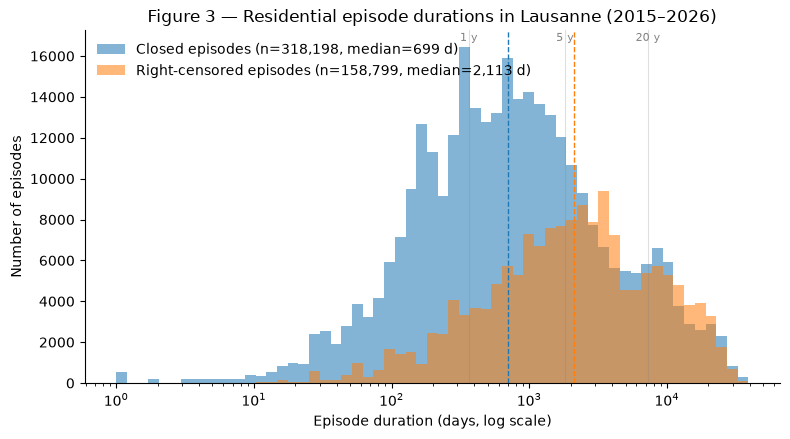

Episodes with duration 0 excluded from plot: 16,915


In [6]:
import matplotlib.pyplot as plt

FIG_DIR = DATA_DIR.parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

ep_plot = episodes[episodes["duree_j"] > 0].copy()
ep_plot["censored"] = ep_plot["date_fin"].isna()

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.logspace(0, np.log10(ep_plot["duree_j"].max()), 60)

for flag, label, color in [(False, "Closed episodes", "#1f77b4"),
                           (True,  "Right-censored episodes", "#ff7f0e")]:
    sub = ep_plot.loc[ep_plot["censored"] == flag, "duree_j"]
    ax.hist(sub, bins=bins, alpha=0.55, label=f"{label} (n={len(sub):,}, "
            f"median={sub.median():,.0f} d)", color=color)
    ax.axvline(sub.median(), color=color, linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_xlabel("Episode duration (days, log scale)")
ax.set_ylabel("Number of episodes")
ax.set_title("Figure 3 — Residential episode durations in Lausanne (2015–2026)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# Reference marks: 1 year, 5 years, 20 years
for d, lbl in [(365, "1 y"), (1825, "5 y"), (7300, "20 y")]:
    ax.axvline(d, color="grey", alpha=0.25, linewidth=0.8)
    ax.text(d, ax.get_ylim()[1]*0.97, lbl, ha="center", fontsize=8, color="grey")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_episode_durations.png", dpi=200)
plt.show()

n_zero = (episodes["duree_j"] == 0).sum()
print(f"Episodes with duration 0 excluded from plot: {n_zero:,}")

## Block 3 — Figure 2: Kaplan-Meier survival curve of time to departure

Person-level survival analysis: time from the start of the observed trajectory to
departure from Lausanne. Event = departure (`target_depart`), right-censoring = still
resident at the end of observation (about half of persons); deaths are treated as censored
(a competing-risks analysis is left as an outlook extension, consistent with the CAS
scope). The Kaplan-Meier estimator handles the censored observations that a naive
duration histogram cannot.

Caveat for the report: snapshot-based trajectories start before the 2015 observation
window (left truncation not modelled here). We therefore stratify by entry type —
post-2015 arrivals give the cleanest curve; the snapshot stratum is descriptive.

The "Born in Lausanne" curve is displayed only to 10 years: births are observed
from 2015 onward, so follow-up is capped at about 11.4 years and the tail beyond
10 years rests on a handful of retroactively registered births, producing a
spurious cliff at the window edge. Together with the left-truncated snapshot
stratum, the two curves illustrate the observation window's two symmetric
biases (left truncation for the 2014 stock, right-edge effects for the birth
cohort).


Excluded from the KM analysis (zero/missing total duration): 37
Post-2015 arrivals        median survival:    3.1 years
Snapshot 2014 stock       median survival:   49.2 years
Born in Lausanne          median survival: at the observation-window edge (~11 y) -- unreliable, not reported


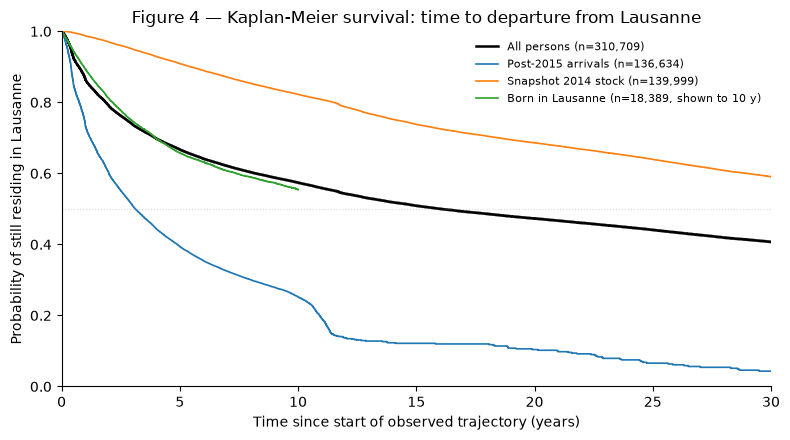


Overall median survival: 16.0 years
Events: 150,731 departures / 310,709 persons (51.5% censored)


In [7]:
from lifelines import KaplanMeierFitter

km = persons[persons["duree_totale_j"] > 0].copy()
km["event"] = km["target_depart"]          # 1 = departure, 0 = censored (incl. deaths)
km["T_years"] = km["duree_totale_j"] / 365.25
print(f"Excluded from the KM analysis (zero/missing total duration): {len(persons) - len(km):,}")

fig, ax = plt.subplots(figsize=(8, 4.5))

# Overall curve
kmf = KaplanMeierFitter()
kmf.fit(km["T_years"], km["event"], label=f"All persons (n={len(km):,})")
kmf.plot_survival_function(ax=ax, ci_show=True, color="black", linewidth=1.8)
med_all = kmf.median_survival_time_

# Stratified by entry type (arrivals = cleanest, no left truncation)
strata = [("arrivee", "Post-2015 arrivals", "#1f77b4"),
          ("snapshot", "Snapshot 2014 stock", "#ff7f0e"),
          ("naissance", "Born in Lausanne", "#2ca02c")]
for key, label, color in strata:
    sub = km[km["debut_type_premier"] == key]
    k = KaplanMeierFitter()
    k.fit(sub["T_years"], sub["event"], label=f"{label} (n={len(sub):,})")
    if key == "naissance":
        # Births are only observed from 2015, so follow-up is capped at ~11.4
        # years: beyond ~10 y the risk set melts to a handful of retroactively
        # registered births and the curve shows a spurious window-edge cliff.
        # Display truncated at 10 years; the naive median sits exactly on that
        # artifact and is therefore not reported.
        sf = k.survival_function_
        sf10 = sf[sf.index <= 10]
        ax.step(sf10.index, sf10.iloc[:, 0], where="post", color=color,
                linewidth=1.2, label=f"{label} (n={len(sub):,}, shown to 10 y)")
        print(f"{label:<25} median survival: at the observation-window edge "
              f"(~11 y) -- unreliable, not reported")
    else:
        k.plot_survival_function(ax=ax, ci_show=False, color=color, linewidth=1.2)
        med = k.median_survival_time_
        print(f"{label:<25} median survival: {med:>6.1f} years"
              if np.isfinite(med) else f"{label:<25} median survival: not reached")

ax.set_xlabel("Time since start of observed trajectory (years)")
ax.set_ylabel("Probability of still residing in Lausanne")
ax.set_title("Figure 4 — Kaplan-Meier survival: time to departure from Lausanne")
ax.set_xlim(0, 30)
ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0.5, color="grey", alpha=0.3, linewidth=0.8, linestyle=":")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_kaplan_meier.png", dpi=200)
plt.show()

print(f"\nOverall median survival: {med_all:.1f} years"
      if np.isfinite(med_all) else "\nOverall median survival: not reached")
print(f"Events: {km['event'].sum():,} departures / {len(km):,} persons "
      f"({1 - km['event'].mean():.1%} censored)")

## Block 4 — Figure 3: Number of residential episodes per person

Person-level view of internal mobility within Lausanne. Most residents (61.5%) have a
single episode, but a long tail reaches up to 17 episodes. The departure rate decreases
monotonically with episode count (52.8% at 1 episode down to ~31% at 5+), so internal
mobility is associated with *retention*, not departure. This motivates `n_episodes` as a
predictive feature and frames the trajectory-clustering deliverable.

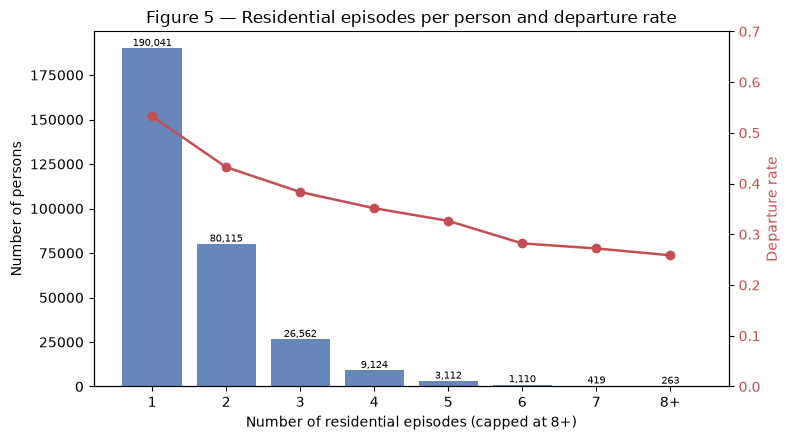

Persons with >8 episodes (folded into last bar): 107


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))

max_show = 8  # cap the tail for readability; report the residual
vc = persons["n_episodes"].clip(upper=max_show).value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color="#4c72b0", alpha=0.85)

# Overlay departure rate by episode count (secondary axis)
dep = persons.groupby(persons["n_episodes"].clip(upper=max_show))["target_depart"].mean()
ax2 = ax.twinx()
ax2.plot(dep.index, dep.values, color="#c44e52", marker="o", linewidth=1.8,
         label="Departure rate")
ax2.set_ylabel("Departure rate", color="#c44e52")
ax2.tick_params(axis="y", labelcolor="#c44e52")
ax2.set_ylim(0, 0.7)

ax.set_xlabel(f"Number of residential episodes (capped at {max_show}+)")
ax.set_ylabel("Number of persons")
ax.set_title("Figure 5 — Residential episodes per person and departure rate")
ax.set_xticks(range(1, max_show + 1))
ax.set_xticklabels([str(i) for i in range(1, max_show)] + [f"{max_show}+"])
ax.spines[["top"]].set_visible(False)

# Annotate counts on bars
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{int(b.get_height()):,}", ha="center", va="bottom", fontsize=7)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_episodes_per_person.png", dpi=200)
plt.show()

print(f"Persons with >{max_show} episodes (folded into last bar): "
      f"{(persons['n_episodes'] > max_show).sum():,}")

## Block 5 — Figure 4: Spatial dimension — departure rate by Lausanne district

This figure anchors the analysis in the geography of Lausanne. Each residential episode
carries a dwelling identifier (EGID), which we map to one of Lausanne's 18 administrative
districts (quartiers) using an official EGID-to-district correspondence table
(11,002 dwellings). We attach the district of each person's first episode and compute the
departure rate per district. Two technical districts are kept separate: 90 (outlying
rural zones) and 99 (unmatched addresses, a data-quality residual). This links the
person-level target to urban space and motivates a spatial reading of residential
mobility.

Composite loc detected (EGID-EWID) -> extracting EGID part
EGID->quartier match rate: 100.0%
Persons with unknown address (99): 65


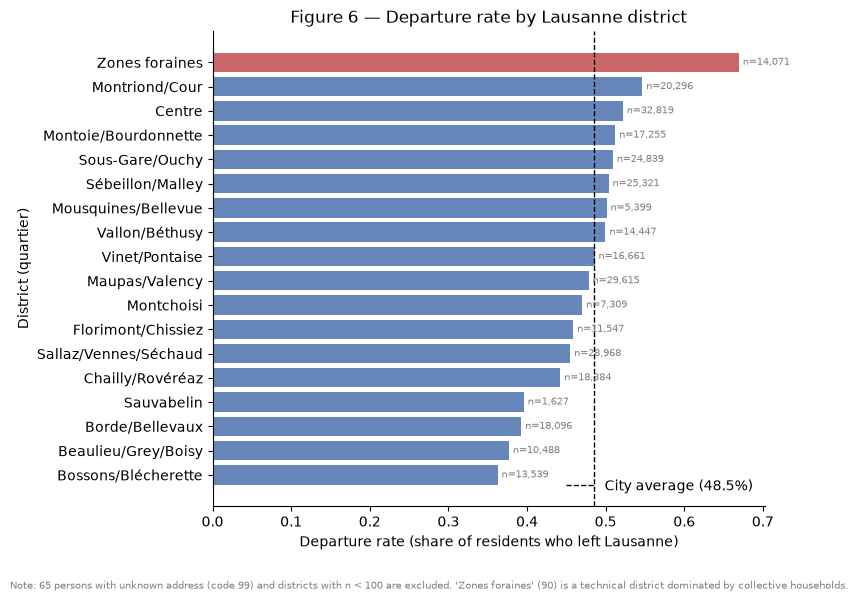

In [9]:
# --- Load EGID -> quartier correspondence ---
ADDR = DATA_DIR.parent / "Adresses.xlsx"
egid_map = pd.read_excel(ADDR, sheet_name="Egid")[["EGID", "NUMQUARTIER"]]
egid_map = egid_map.drop_duplicates("EGID")           # 34 duplicated EGID -> keep first
quartiers = pd.read_excel(ADDR, sheet_name="Quartier").rename(
    columns={"Nr": "NUMQUARTIER", "Nom": "quartier_nom"})

# --- Extract EGID from episode 'loc' (handles pure EGID or 'EGID-EWID' composite) ---
first_ep = (episodes.sort_values(["id_projet", "ep_num"])
            .groupby("id_projet").first().reset_index())

loc_str = first_ep["loc"].astype(str)
if loc_str.str.contains("-").any():
    print("Composite loc detected (EGID-EWID) -> extracting EGID part")
    first_ep["EGID"] = pd.to_numeric(loc_str.str.split("-").str[0], errors="coerce")
else:
    print("Pure EGID loc detected")
    first_ep["EGID"] = pd.to_numeric(loc_str, errors="coerce")

# --- Attach quartier to first episode, then to persons ---
first_ep = first_ep.merge(egid_map, on="EGID", how="left")
first_ep["NUMQUARTIER"] = first_ep["NUMQUARTIER"].fillna(99).astype(int)  # unmatched -> 99

geo = persons.merge(
    first_ep[["id_projet", "NUMQUARTIER"]], on="id_projet", how="left"
).merge(quartiers, on="NUMQUARTIER", how="left")

match_rate = (geo["NUMQUARTIER"] != 99).mean()
print(f"EGID->quartier match rate: {match_rate:.1%}")
print(f"Persons with unknown address (99): {(geo['NUMQUARTIER']==99).sum():,}")

# --- Departure rate per district ---
by_q = (geo.groupby(["NUMQUARTIER", "quartier_nom"])
        .agg(n=("target_depart", "size"), taux_depart=("target_depart", "mean"))
        .reset_index())
by_q = by_q[by_q["n"] >= 100].sort_values("taux_depart")  # drop tiny districts

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c44e52" if q in (90, 99) else "#4c72b0" for q in by_q["NUMQUARTIER"]]
ax.barh(by_q["quartier_nom"], by_q["taux_depart"], color=colors, alpha=0.85)
ax.axvline(persons["target_depart"].mean(), color="black", linestyle="--",
           linewidth=1, label=f"City average ({persons['target_depart'].mean():.1%})")

ax.set_xlabel("Departure rate (share of residents who left Lausanne)")
ax.set_ylabel("District (quartier)")
ax.set_title("Figure 6 — Departure rate by Lausanne district")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
for i, (r, n) in enumerate(zip(by_q["taux_depart"], by_q["n"])):
    ax.text(r + 0.005, i, f"n={n:,}", va="center", fontsize=7, color="grey")

fig.tight_layout(rect=(0, 0.05, 1, 1))
n_unknown = int((geo["NUMQUARTIER"] == 99).sum())
fig.text(0.01, 0.01,
         f"Note: {n_unknown:,} persons with unknown address (code 99) and districts with "
         f"n < 100 are excluded. 'Zones foraines' (90) is a technical district dominated "
         f"by collective households.",
         fontsize=7, color="grey")
fig.savefig(FIG_DIR / "fig6_departure_by_district.png", dpi=200)
plt.show()

In [10]:
# --- Table 2 (report): analytical population characteristics -----------------
# Composition of the analytical population and raw departure rate per group.

import pandas as pd

pers = pd.read_parquet(DATA_DIR / "persons_analytical_enriched.parquet")
assert len(pers) == 310_746

rows = []

def add_block(series, label, order=None):
    g = (pers.groupby(series, dropna=False, observed=True)["target_depart"]
             .agg(n="size", taux="mean"))
    g = g.loc[order] if order is not None else g.sort_values("n", ascending=False)
    for cat, r in g.iterrows():
        rows.append({"Variable": label, "Category": str(cat), "n": int(r["n"]),
                     "share_pct": 100 * r["n"] / len(pers),
                     "departure_rate_pct": 100 * r["taux"]})

add_block(pers["sexe"], "Sex")
add_block(pers["nat_groupe"], "Nationality group")
add_block(pers["permis_groupe"], "Permit group")
add_block(pers["menage_type"], "Household type")
add_block(pers["debut_type_premier"], "Entry type",
          order=["arrivee", "snapshot", "naissance", "reprise", "transition"])

age_bands = pd.cut(pers["age_entree"], [0, 18, 30, 45, 65, 120], right=False,
                   labels=["0-17", "18-29", "30-44", "45-64", "65+"])
add_block(age_bands, "Age at entry",
          order=["0-17", "18-29", "30-44", "45-64", "65+"])

table2 = pd.DataFrame(rows).round({"share_pct": 1, "departure_rate_pct": 1})
print(f"Analytical population: {len(pers):,} | "
      f"overall departure rate: {pers['target_depart'].mean():.1%}\n")
print(table2.to_string(index=False))


Analytical population: 310,746 | overall departure rate: 48.5%

         Variable      Category      n  share_pct  departure_rate_pct
              Sex             M 156372       50.3                50.3
              Sex             F 154364       49.7                46.7
              Sex             I     10        0.0                70.0
Nationality group            CH 127325       41.0                37.5
Nationality group       UE_AELE 118662       38.2                58.0
Nationality group         tiers  64759       20.8                52.9
     Permit group            CH 127325       41.0                37.5
     Permit group             P  91105       29.3                65.0
     Permit group             C  42730       13.8                37.0
     Permit group             B  39132       12.6                57.2
     Permit group         asile   6837        2.2                46.0
     Permit group             L   2718        0.9                73.4
     Permit group         

In [12]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/mnt/o/09_STATISTIQUES/09_04_Explorations/MR/CAS ADS/Final project/data")

pers = pd.read_parquet(DATA_DIR / "persons_analytical_enriched.parquet")

# District of the first episode: EGID -> quartier (same logic as NB6 Fig. 4 / NB7 Block 0)
episodes = pd.read_parquet(DATA_DIR / "episodes.parquet",
                           columns=["id_projet", "ep_num", "loc"])
first_ep = (episodes.sort_values(["id_projet", "ep_num"])
                    .groupby("id_projet", as_index=False).first())
first_ep["egid"] = first_ep["loc"].str.split("-").str[0]

adr = (pd.read_excel(DATA_DIR.parent / "Adresses.xlsx", sheet_name="Egid")
         [["EGID", "NUMQUARTIER"]].drop_duplicates("EGID"))
adr["EGID"] = adr["EGID"].astype(str)
adr["NUMQUARTIER"] = adr["NUMQUARTIER"].astype(str)

first_ep = first_ep.merge(adr, left_on="egid", right_on="EGID", how="left")
pers = pers.merge(first_ep[["id_projet", "NUMQUARTIER"]], on="id_projet", how="left")

by_q = (pers.groupby(pers["NUMQUARTIER"].fillna("inconnu"))["target_depart"]
            .agg(n="size", taux="mean")
            .sort_values("taux", ascending=False))
print(by_q.to_string(float_format="{:.1%}".format))
print(f"\nZones foraines (90): {by_q.loc['90', 'taux']:.1%} (n = {int(by_q.loc['90', 'n']):,})")

                 n  taux
NUMQUARTIER             
90           14071 66.9%
5            20296 54.6%
1            32819 52.2%
4            17255 51.2%
6            24839 50.9%
3            25321 50.4%
9             5399 50.1%
10           14447 50.0%
15           16661 48.6%
2            29615 47.8%
7             7309 47.0%
inconnu         65 46.2%
8            11547 45.9%
12           28968 45.5%
11           18384 44.2%
13            1627 39.6%
14           18096 39.3%
17           10488 37.7%
16           13539 36.3%

Zones foraines (90): 66.9% (n = 14,071)
